In [28]:
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
import pytorch_lightning as pl
from generative.losses.adversarial_loss import PatchAdversarialLoss
from generative.losses.perceptual import PerceptualLoss
from generative.networks import nets
from monai import transforms
from monai.networks.nets import UNet
import SimpleITK as sitk
from matplotlib import pyplot as plt

device = torch.device("cuda")

In [29]:
class GaussianNoise(nn.Module):    
    def __init__(self, mean=0.0, std=0.05):
        super(GaussianNoise, self).__init__()
        self.mean = torch.tensor(mean)
        self.std = torch.tensor(std)
    def forward(self, x):
        if self.training:
            return x + torch.normal(mean=self.mean, std=self.std, size=x.size(), device=x.device)
        return x
    
class RandCoarseShuffle(nn.Module):    
    def __init__(self, prob=0.75, holes=16, spatial_size=32):
        super(RandCoarseShuffle, self).__init__()
        self.t = transforms.RandCoarseShuffle(prob=prob, holes=holes, spatial_size=spatial_size)
    def forward(self, x):
        if self.training:
            return self.t(x)
        return x

class SaltAndPepper(nn.Module):    
    def __init__(self, prob=0.05):
        super(SaltAndPepper, self).__init__()
        self.prob = prob
    def __call__(self, x):
        noise_tensor = torch.rand(x.shape)
        salt = torch.max(x)
        pepper = torch.min(x)
        x[noise_tensor < self.prob/2] = salt
        x[noise_tensor > 1-self.prob/2] = pepper
        return x
    

transform = transforms.Compose([
    # transforms.EnsureChannelFirst(channel_dim="1"),  # Ensures a single channel if input has none
    transforms.ToTensor()
])

In [32]:
class AutoEncoderKLPaired(pl.LightningModule):
    def __init__(self, **kwargs):
        super().__init__()
        self.save_hyperparameters()

        self.autoencoderkl = UNet(
            spatial_dims=2,
            in_channels=1,
            out_channels=1,
            channels=(64, 128, 256, 512),
            num_res_units=2,
            strides = (2, 2, 2)
        )

        self.perceptual_loss = PerceptualLoss(spatial_dims=2, network_type="alex")

        self.automatic_optimization = False

        self.discriminator = nets.PatchDiscriminator(spatial_dims=2, num_layers_d=3, num_channels=64, in_channels=1, out_channels=1)        

        self.adversarial_loss = PatchAdversarialLoss(criterion="least_squares")        

        self.noise_transform = torch.nn.Sequential(
            GaussianNoise(0.0, 0.05),
            RandCoarseShuffle(),
            SaltAndPepper()
        )
        
    def configure_optimizers(self):
        optimizer_g = optim.AdamW(self.autoencoderkl.parameters(),
                                lr=1e-4,
                                weight_decay=0.01)
        
        optimizer_d = optim.AdamW(self.discriminator.parameters(),
                                lr=1e-4,
                                weight_decay=0.01)

        return [optimizer_g, optimizer_d]

    def training_step(self, train_batch, batch_idx):
        x = train_batch[0]
        y = train_batch[1]
        optimizer_g, optimizer_d = self.optimizers()
        
        optimizer_g.zero_grad()

        reconstruction = self.autoencoderkl(x)

        recons_loss = F.l1_loss(reconstruction.float(), y.float())
        p_loss = self.perceptual_loss(reconstruction.float(), y.float())
        loss_g = recons_loss  + (0.001 * p_loss)

        if self.trainer.current_epoch >= 0:
            logits_fake = self.discriminator(reconstruction.contiguous().float())[-1]
            generator_loss = self.adversarial_loss(logits_fake, target_is_real=True, for_discriminator=False)
            loss_g += 0.01 * generator_loss

        loss_g.backward()
        optimizer_g.step()
        
        loss_d = 0
        if self.trainer.current_epoch >= 0:
            
            optimizer_d.zero_grad()

            logits_fake = self.discriminator(reconstruction.contiguous().detach())[-1]
            loss_d_fake = self.adversarial_loss(logits_fake, target_is_real=False, for_discriminator=True)
            logits_real = self.discriminator(y.contiguous().detach())[-1]
            loss_d_real = self.adversarial_loss(logits_real, target_is_real=True, for_discriminator=True)
            discriminator_loss = (loss_d_fake + loss_d_real) * 0.5

            loss_d = 0.01 * discriminator_loss

            loss_d.backward()
            optimizer_d.step()

        self.log("train_loss_g", loss_g)
        self.log("train_loss_d", loss_d)

        return {"train_loss_g": loss_g, "train_loss_d": loss_d}

        
    def validation_step(self, val_batch, batch_idx):
        
        x = val_batch[0]
        y = val_batch[1]
        # with autocast(enabled=True):
        #     reconstruction, z_mu, z_sigma = self.autoencoderkl(x)
        #     recon_loss = F.l1_loss(x.float(), reconstruction.float())

        reconstruction = self.autoencoderkl(x)
        recon_loss = F.l1_loss(y.float(), reconstruction.float())

        self.log("val_loss", recon_loss, sync_dist=True)


    def forward(self, images): 
        return self.autoencoderkl(images)


In [38]:
# Load the trained model
model = AutoEncoderKLPaired()
state_dict = torch.load("/mnt/raid/home/ajarry/data/autoencoder/unet_200e_4layers/model.pth")
model.load_state_dict(state_dict=state_dict, strict=False)
model = model.to(device)
model.eval()  # Set to evaluation mode

type_frame = "M"
frame = 60
# Load an image (grayscale)
image_path = "/mnt/raid/C1_ML_Analysis/simulated_data_export/placenta_simu/FAM-025-0664-4_label11/" + type_frame + "_diffusor/"+ str(frame) + ".nrrd"
target_path = "/mnt/raid/C1_ML_Analysis/simulated_data_export/placenta_simu/FAM-025-0664-4_label11/" + type_frame +"_guided/" + str(frame) + ".nrrd"
image = sitk.GetArrayFromImage(sitk.ReadImage(image_path))
target = sitk.GetArrayFromImage(sitk.ReadImage(target_path))
print(image.shape)

input_image = transform(image).unsqueeze(0).unsqueeze(0).to(device)
print(input_image.shape)

(256, 256)
torch.Size([1, 1, 256, 256])


torch.Size([1, 1, 256, 256])
<class 'numpy.ndarray'>
(256, 256)


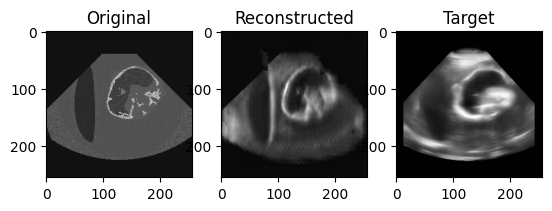

In [39]:
with torch.no_grad():
    output = model(input_image)
print(output.shape)
decoded_image = output.cpu().numpy().squeeze()
print(type(decoded_image))
print(decoded_image.shape)

fig, ax = plt.subplots(1, 3)
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Original")
ax[1].imshow(decoded_image, cmap="gray")
ax[1].set_title("Reconstructed")
ax[2].imshow(target, cmap="gray")
ax[2].set_title("Target")

plt.show()